# Tasks 5 and 6 (revised)

This notebook fixes the main issues in the earlier version:

1. it is executed and includes the resulting outputs and figures,
2. the optional gap plot uses a **numerical reference objective** `f_ref` instead of calling it the exact optimum,
3. the trade-off curve includes an explicit **stability diagnostic** based on the objective values from the last 1000 AGD iterations.


In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")

# Load and preprocess data exactly as in the assignment.
X, y = sklearn.datasets.load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
y = 2 * y - 1  # remap labels from {0, 1} to {-1, +1}

N, n = X.shape
X_tilde = np.hstack([X, np.ones((N, 1))])
X_tilde_norm_sq = np.linalg.norm(X_tilde, ord=2) ** 2

print(f"N = {N}, n = {n}")
print(f"||X_tilde||_2^2 = {X_tilde_norm_sq:.6f}")


N = 569, n = 30
||X_tilde||_2^2 = 7557.234771


In [2]:
from collections import deque


def phi(s):
    return np.logaddexp(0.0, s)


def sigma(s):
    out = np.empty_like(s, dtype=float)
    pos = s >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-s[pos]))
    neg = ~pos
    ex = np.exp(s[neg])
    out[neg] = ex / (1.0 + ex)
    return out


def apply_D(theta):
    # D = I - e_{n+1} e_{n+1}^T, so the last entry (bias) is not regularized.
    out = theta.copy()
    out[-1] = 0.0
    return out


def regularizer(theta):
    Dt = apply_D(theta)
    return 0.5 * np.dot(Dt, Dt)


def nll(theta):
    return np.sum(phi(-y * (X_tilde @ theta)))


def objective(theta, gamma):
    return nll(theta) + gamma * regularizer(theta)


def grad_objective(theta, gamma):
    z = -y * (X_tilde @ theta)
    return -(X_tilde.T @ (y * sigma(z))) + gamma * apply_D(theta)


def lipschitz_constant(gamma):
    return gamma + 0.25 * X_tilde_norm_sq


def gradient_descent(theta0, gamma, max_iter=1000, tol=0.0, record_history=True):
    step = 1.0 / lipschitz_constant(gamma)
    theta = theta0.copy()
    f = objective(theta, gamma)
    gnorm = np.linalg.norm(grad_objective(theta, gamma))

    history = [f] if record_history else None
    grad_norms = [gnorm] if record_history else None

    converged = gnorm <= tol
    k_done = 0

    while (not converged) and k_done < max_iter:
        theta = theta - step * grad_objective(theta, gamma)
        k_done += 1

        f = objective(theta, gamma)
        gnorm = np.linalg.norm(grad_objective(theta, gamma))
        converged = gnorm <= tol

        if record_history:
            history.append(f)
            grad_norms.append(gnorm)

    return {
        "theta": theta,
        "history": np.array(history) if record_history else None,
        "grad_norms": np.array(grad_norms) if record_history else None,
        "iterations": k_done,
        "converged": converged,
        "final_objective": f,
        "final_grad_norm": gnorm,
        "step": step,
    }


def accelerated_gradient(
    theta0,
    gamma,
    max_iter=1000,
    tol=0.0,
    record_history=True,
    keep_best=False,
    tail_window=None,
):
    step = 1.0 / lipschitz_constant(gamma)
    x = theta0.copy()
    y_k = theta0.copy()
    a_k = 1.0

    f = objective(x, gamma)
    gnorm = np.linalg.norm(grad_objective(x, gamma))

    history = [f] if record_history else None
    grad_norms = [gnorm] if record_history else None
    tail_values = deque([f], maxlen=tail_window) if tail_window is not None else None

    if keep_best:
        best_theta = x.copy()
        best_objective = f
    else:
        best_theta = None
        best_objective = None

    converged = gnorm <= tol
    k_done = 0

    while (not converged) and k_done < max_iter:
        x_next = y_k - step * grad_objective(y_k, gamma)
        a_next = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * a_k * a_k))
        y_next = x_next + ((a_k - 1.0) / a_next) * (x_next - x)

        x, y_k, a_k = x_next, y_next, a_next
        k_done += 1

        f = objective(x, gamma)
        gnorm = np.linalg.norm(grad_objective(x, gamma))
        converged = gnorm <= tol

        if record_history:
            history.append(f)
            grad_norms.append(gnorm)
        if tail_values is not None:
            tail_values.append(f)
        if keep_best and f < best_objective:
            best_objective = f
            best_theta = x.copy()

    result = {
        "theta": x,
        "history": np.array(history) if record_history else None,
        "grad_norms": np.array(grad_norms) if record_history else None,
        "iterations": k_done,
        "converged": converged,
        "final_objective": f,
        "final_grad_norm": gnorm,
        "step": step,
    }

    if keep_best:
        result["best_theta"] = best_theta
        result["best_objective"] = best_objective
        result["best_grad_norm"] = np.linalg.norm(grad_objective(best_theta, gamma))
    if tail_values is not None:
        tail_array = np.array(tail_values, dtype=float)
        result["tail_values"] = tail_array
        result["tail_span"] = float(tail_array.max() - tail_array.min())

    return result


## Task 5

We compare GD and AGD for `gamma = 3` with `theta_0 = 0`. The assignment asks for the objective value on a logarithmic scale. I also include a second, purely diagnostic plot against a **high-accuracy numerical reference objective** `f_ref`; this is **not** claimed to be the exact optimum.


In [3]:
gamma = 3.0
theta0 = np.zeros(n + 1)

gd_result = gradient_descent(theta0, gamma, max_iter=1000, tol=0.0, record_history=True)
agd_result = accelerated_gradient(theta0, gamma, max_iter=1000, tol=0.0, record_history=True)
ref_result = accelerated_gradient(theta0, gamma, max_iter=50000, tol=1e-10, record_history=False)
f_ref = objective(ref_result["theta"], gamma)

gd_monotone = np.all(np.diff(gd_result["history"]) <= 1e-12)
agd_monotone = np.all(np.diff(agd_result["history"]) <= 1e-12)

print(f"L = {lipschitz_constant(gamma):.6f}")
print(f"step size = {gd_result['step']:.6e}")
print(
    f"Reference AGD run converged: {ref_result['converged']} "
    f"after {ref_result['iterations']} iterations"
)
print(f"Reference objective f_ref = {f_ref:.12f}")
print(f"GD final objective  = {gd_result['final_objective']:.12f}")
print(f"AGD final objective = {agd_result['final_objective']:.12f}")
print(f"GD final gap to f_ref  = {gd_result['final_objective'] - f_ref:.6e}")
print(f"AGD final gap to f_ref = {agd_result['final_objective'] - f_ref:.6e}")
print(f"GD objective monotone over 1000 iterations:  {gd_monotone}")
print(f"AGD objective monotone over 1000 iterations: {agd_monotone}")


L = 1892.308693
step size = 5.284550e-04
Reference AGD run converged: True after 15424 iterations
Reference objective f_ref = 48.077769398149
GD final objective  = 48.088429761104
AGD final objective = 48.077770913405
GD final gap to f_ref  = 1.066036e-02
AGD final gap to f_ref = 1.515255e-06
GD objective monotone over 1000 iterations:  True
AGD objective monotone over 1000 iterations: False


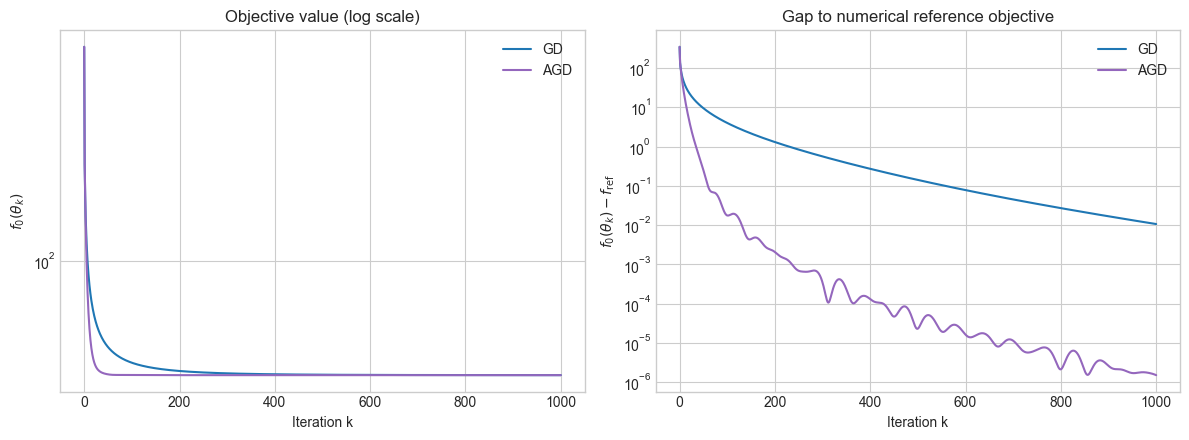

In [4]:
gap_gd = np.maximum(gd_result["history"] - f_ref, 1e-16)
gap_agd = np.maximum(agd_result["history"] - f_ref, 1e-16)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].semilogy(gd_result["history"], label="GD", color="tab:blue")
axes[0].semilogy(agd_result["history"], label="AGD", color="tab:purple")
axes[0].set_xlabel("Iteration k")
axes[0].set_ylabel(r"$f_0(\theta_k)$")
axes[0].set_title("Objective value (log scale)")
axes[0].legend()

axes[1].semilogy(gap_gd, label="GD", color="tab:blue")
axes[1].semilogy(gap_agd, label="AGD", color="tab:purple")
axes[1].set_xlabel("Iteration k")
axes[1].set_ylabel(r"$f_0(\theta_k) - f_{\mathrm{ref}}$")
axes[1].set_title("Gap to numerical reference objective")
axes[1].legend()

plt.tight_layout()
plt.show()


For this instance, GD decreases monotonically throughout the 1000 recorded iterations, while AGD is non-monotone but reaches the reference objective level much faster. This is the qualitative behavior we expect on a smooth problem: GD is a descent method, whereas AGD trades monotonicity for faster practical progress.

The right-hand plot is only an **empirical diagnostic** because it uses a numerical reference objective `f_ref` rather than the exact optimum. It still makes the practical difference clear: after 1000 iterations, AGD is already extremely close to the reference objective, whereas GD is still visibly above it.


## Task 6

For the trade-off curve we use 20 values of `gamma` in `[10^-3, 10^3]`, spaced logarithmically, and warm-start each solve from the previous one. Each point is computed with 50,000 AGD iterations.

Because AGD is non-monotone, I report the **objective span over the last 1000 iterations** as a stability diagnostic. A small span means the plotted point is numerically stable even if the gradient norm is not tiny for the smallest values of `gamma`.


In [5]:
gammas = np.logspace(-3, 3, 20)

reg_terms = np.empty(len(gammas))
nll_terms = np.empty(len(gammas))
tail_spans = np.empty(len(gammas))
best_grad_norms = np.empty(len(gammas))

theta = np.zeros(n + 1)
for i, g in enumerate(gammas):
    result = accelerated_gradient(
        theta,
        g,
        max_iter=50000,
        tol=0.0,
        record_history=False,
        keep_best=True,
        tail_window=1000,
    )
    theta = result["best_theta"]
    reg_terms[i] = regularizer(theta)
    nll_terms[i] = nll(theta)
    tail_spans[i] = result["tail_span"]
    best_grad_norms[i] = result["best_grad_norm"]

print(f"gamma range: [{gammas[0]:.0e}, {gammas[-1]:.0e}]")
print(f"max tail span over last 1000 AGD iterations: {tail_spans.max():.6e}")
print(f"median tail span over last 1000 AGD iterations: {np.median(tail_spans):.6e}")
print(f"max gradient norm at the selected iterate: {best_grad_norms.max():.6e}")
print(f"regularizer values decrease with gamma: {np.all(np.diff(reg_terms) <= 1e-10)}")
print(f"NLL values increase with gamma: {np.all(np.diff(nll_terms) >= -1e-10)}")

for idx in [0, len(gammas) // 2, len(gammas) - 1]:
    print(
        f"gamma = {gammas[idx]:9.3e} | "
        f"0.5||D theta||^2 = {reg_terms[idx]:11.6f} | "
        f"NLL = {nll_terms[idx]:10.6f} | "
        f"tail span = {tail_spans[idx]:.3e}"
    )


gamma range: [1e-03, 1e+03]
max tail span over last 1000 AGD iterations: 5.107098e-06
median tail span over last 1000 AGD iterations: 2.842171e-14
max gradient norm at the selected iterate: 2.235317e-04
regularizer values decrease with gamma: True
NLL values increase with gamma: True
gamma = 1.000e-03 | 0.5||D theta||^2 = 1218.156976 | NLL =  14.179824 | tail span = 5.107e-06
gamma = 1.438e+00 | 0.5||D theta||^2 =    5.980461 | NLL =  32.055152 | tail span = 1.421e-14
gamma = 1.000e+03 | 0.5||D theta||^2 =    0.055789 | NLL = 194.576955 | tail span = 0.000e+00


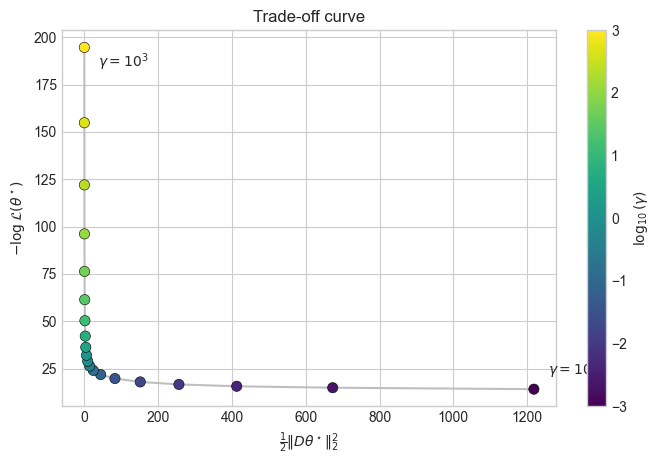

In [6]:
plt.figure(figsize=(7, 4.75))
plt.plot(reg_terms, nll_terms, color="0.75", linewidth=1.5, zorder=1)
scatter = plt.scatter(
    reg_terms,
    nll_terms,
    c=np.log10(gammas),
    cmap="viridis",
    s=55,
    edgecolor="black",
    linewidth=0.4,
    zorder=2,
)
plt.xlabel(r"$\frac{1}{2}\|D\theta^\star\|_2^2$")
plt.ylabel(r"$-\log \mathcal{L}(\theta^\star)$")
plt.title("Trade-off curve")
cbar = plt.colorbar(scatter)
cbar.set_label(r"$\log_{10}(\gamma)$")

plt.annotate(
    r"$\gamma = 10^{-3}$",
    xy=(reg_terms[0], nll_terms[0]),
    xytext=(10, 10),
    textcoords="offset points",
)
plt.annotate(
    r"$\gamma = 10^{3}$",
    xy=(reg_terms[-1], nll_terms[-1]),
    xytext=(10, -14),
    textcoords="offset points",
)

plt.tight_layout()
plt.show()


The computed points show the expected trade-off: increasing `gamma` shrinks the regularization term `0.5 ||D theta||_2^2` and increases the negative log-likelihood. The bend in the curve occurs at intermediate values of `gamma`, where a moderate loss in data fit buys a large reduction in model size. The color bar and endpoint annotations make the direction of increasing `gamma` explicit.

This should be interpreted as an **estimated** trade-off curve coming from numerical optimization. The reported tail spans show that the plotted points are numerically stable, with worst-case variation on the order of `1e-6` over the last 1000 AGD iterations.
